# Notebook 3 — Paper Clustering Comparison (CVI Replication)

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Replicates cluster validity indices (CVIs) from Garcia-Rudolph et al. (2020) for direct comparison:
- Average Silhouette Width
- Pearson Gamma Index
- Entropy
- Dunn Index
- Within-Between Cluster Ratio

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
from scipy.spatial.distance import cdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

RESULTS_DIR = '../results'
IMPUTED_DIR = '../data/imputed_csv'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load data
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

ELIGIBLE_VARS = eda['ELIGIBLE_VARS']
X_mice = pd.read_csv(os.path.join(IMPUTED_DIR, 'Imputed_MICE.csv'), index_col=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mice[ELIGIBLE_VARS])
print(f'Data shape: {X_scaled.shape}')

Data shape: (22075, 15)


In [3]:
def dunn_index(X, labels):
    """Compute Dunn Index: ratio of minimum inter-cluster distance to maximum intra-cluster diameter."""
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0
    
    # Intra-cluster diameters
    max_intra = 0
    for lab in unique_labels:
        members = X[labels == lab]
        if len(members) > 1:
            dists = pairwise_distances(members)
            max_intra = max(max_intra, np.max(dists))
    
    # Inter-cluster distances (min distance between clusters)
    min_inter = np.inf
    for i, lab_i in enumerate(unique_labels):
        for lab_j in unique_labels[i+1:]:
            dists = pairwise_distances(X[labels == lab_i], X[labels == lab_j])
            min_inter = min(min_inter, np.min(dists))
    
    return min_inter / max_intra if max_intra > 0 else 0.0

def cluster_entropy(labels):
    """Compute entropy of cluster size distribution."""
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-10))

def within_between_ratio(X, labels):
    """Compute within-cluster to between-cluster variance ratio."""
    overall_mean = X.mean(axis=0)
    unique_labels = np.unique(labels)
    
    within_ss = 0
    between_ss = 0
    
    for lab in unique_labels:
        members = X[labels == lab]
        cluster_mean = members.mean(axis=0)
        within_ss += np.sum((members - cluster_mean) ** 2)
        between_ss += len(members) * np.sum((cluster_mean - overall_mean) ** 2)
    
    return within_ss / between_ss if between_ss > 0 else np.inf

def pearson_gamma(X, labels):
    """Compute Pearson Gamma index (correlation between distance and cluster membership)."""
    n = min(5000, len(X))  # Subsample for computational tractability
    if len(X) > n:
        idx = np.random.choice(len(X), n, replace=False)
        X_sub = X[idx]
        labels_sub = labels[idx]
    else:
        X_sub = X
        labels_sub = labels
    
    dists = pairwise_distances(X_sub).ravel()
    same_cluster = (labels_sub[:, None] == labels_sub[None, :]).astype(float).ravel()
    
    # Remove diagonal
    mask = np.ones(len(X_sub) * len(X_sub), dtype=bool)
    mask[::len(X_sub)+1] = False
    
    return np.corrcoef(dists[mask], 1 - same_cluster[mask])[0, 1]

In [4]:
# Compute CVIs for K-Means with k=2-6
k_range = range(2, 7)
cvi_results = []

for k in k_range:
    print(f'Computing CVIs for k={k}...')
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    gamma = pearson_gamma(X_scaled, labels)
    entropy = cluster_entropy(labels)
    dunn = dunn_index(X_scaled[:5000], labels[:5000])  # Subsample for Dunn (expensive)
    wb_ratio = within_between_ratio(X_scaled, labels)
    
    cvi_results.append({
        'k': k,
        'Silhouette': round(sil, 4),
        'Pearson Gamma': round(gamma, 4),
        'Entropy': round(entropy, 4),
        'Dunn Index': round(dunn, 4),
        'W/B Ratio': round(wb_ratio, 4)
    })

cvi_df = pd.DataFrame(cvi_results)
print('\n=== Cluster Validity Indices ===')
print(cvi_df.to_string(index=False))

Computing CVIs for k=2...


Computing CVIs for k=3...


Computing CVIs for k=4...


Computing CVIs for k=5...


Computing CVIs for k=6...



=== Cluster Validity Indices ===
 k  Silhouette  Pearson Gamma  Entropy  Dunn Index  W/B Ratio
 2      0.4127         0.5901   0.6415      0.0246     3.1587
 3      0.1959         0.3967   1.2817      0.0070     1.7560
 4      0.2019         0.4202   1.3489      0.0087     1.3910
 5      0.1430         0.3887   1.7849      0.0165     1.1726
 6      0.1397         0.3916   1.9340      0.0202     1.0633


In [5]:
# Silhouette interpretation thresholds (Garcia-Rudolph et al.)
print('\nSilhouette Interpretation (Garcia-Rudolph et al., 2020):')
print('  > 0.71: Strong structure')
print('  0.51-0.70: Reasonable structure')
print('  0.26-0.50: Weak structure')
print('  ≤ 0.25: No substantial structure')

for _, row in cvi_df.iterrows():
    s = row['Silhouette']
    if s > 0.71:
        interp = 'Strong'
    elif s > 0.50:
        interp = 'Reasonable'
    elif s > 0.25:
        interp = 'Weak'
    else:
        interp = 'No substantial'
    print(f'  k={int(row["k"])}: Silhouette={s:.4f} → {interp} structure')


Silhouette Interpretation (Garcia-Rudolph et al., 2020):
  > 0.71: Strong structure
  0.51-0.70: Reasonable structure
  0.26-0.50: Weak structure
  ≤ 0.25: No substantial structure
  k=2: Silhouette=0.4127 → Weak structure
  k=3: Silhouette=0.1959 → No substantial structure
  k=4: Silhouette=0.2019 → No substantial structure
  k=5: Silhouette=0.1430 → No substantial structure
  k=6: Silhouette=0.1397 → No substantial structure


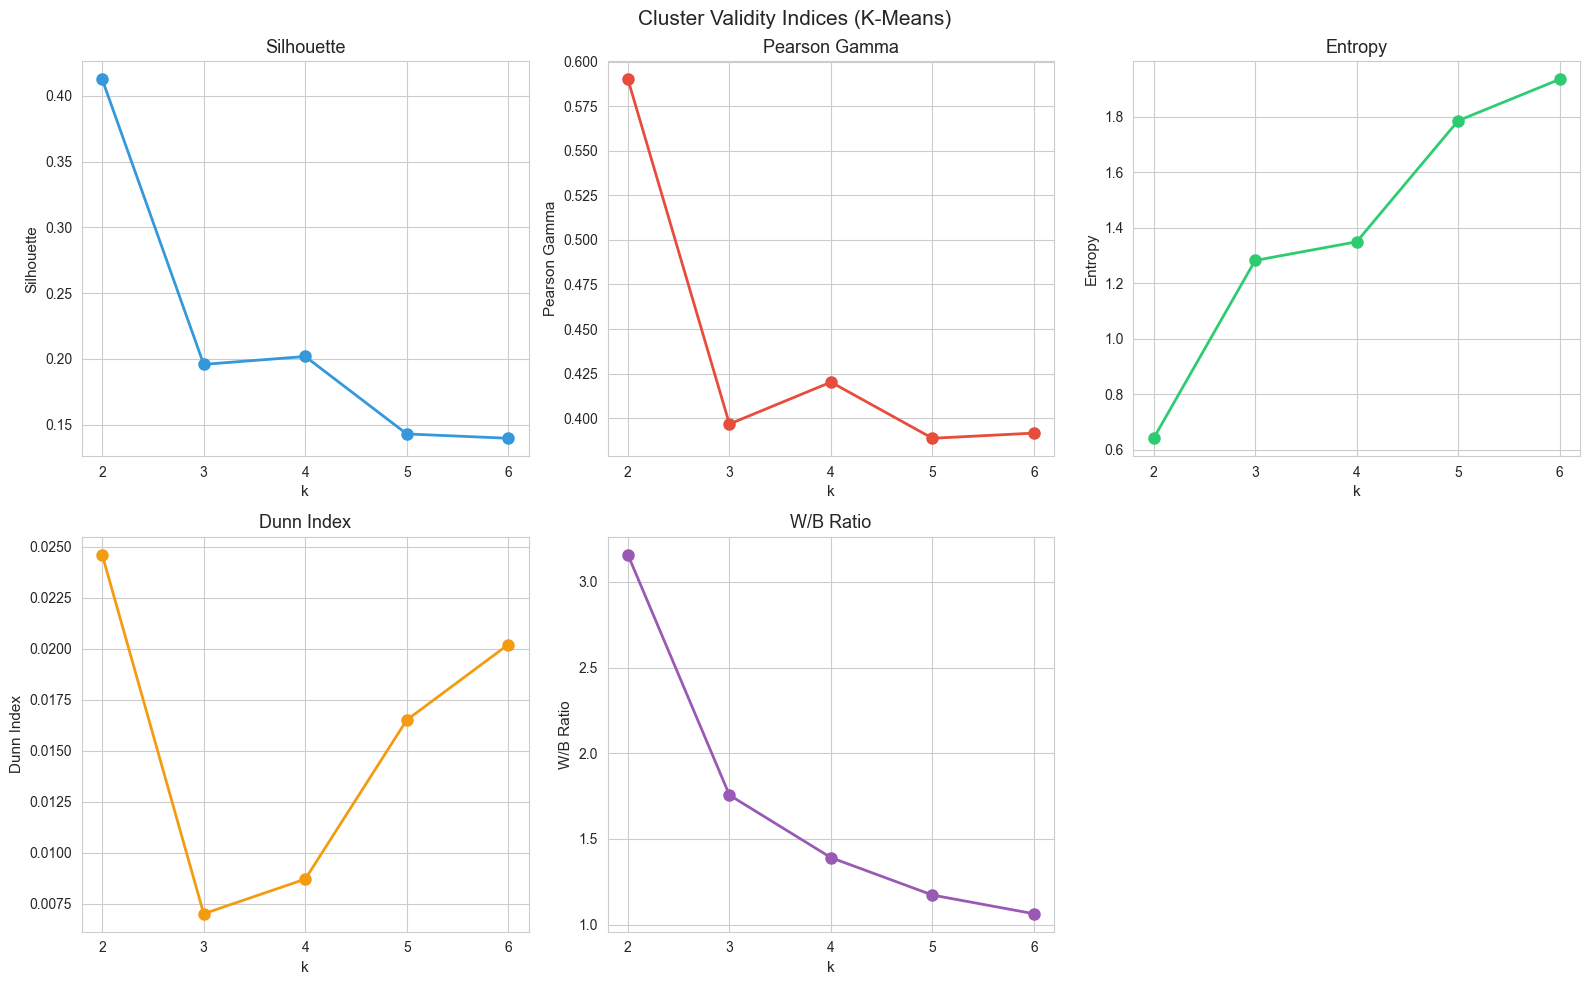


=== Notebook 3 Complete ===


In [6]:
# Save CVI results
cvi_df.to_csv(os.path.join(RESULTS_DIR, 'CVI_Comparison.csv'), index=False)

# CVI comparison figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Silhouette', 'Pearson Gamma', 'Entropy', 'Dunn Index', 'W/B Ratio']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes.flat[idx]
    ax.plot(cvi_df['k'], cvi_df[metric], 'o-', color=color, linewidth=2, markersize=8)
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=13)
    ax.set_xticks(list(k_range))

axes.flat[-1].axis('off')  # Hide unused subplot
plt.suptitle('Cluster Validity Indices (K-Means)', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cvi_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print('\n=== Notebook 3 Complete ===')